## Calculate temperature profiles under different modelling assumptions

In [1]:
# Set directory
ROOT_DIR = abspath(joinpath(pwd(),"../../"))
if !haskey(ENV, "RAD_DIR")
    ENV["RAD_DIR"] = joinpath(ROOT_DIR,"socrates")
end
println(ROOT_DIR)

/home/harrison/Projects/AGNI/


In [2]:
# Import AGNI
using Pkg
Pkg.activate(ROOT_DIR)
using AGNI

# Normal logging from AGNI module
AGNI.setup_logging("",1)

  Activating project at `~/Projects/AGNI`
[ Info: Precompiling AGNI [ede838c1-9ec3-4ebe-8ae8-da4091b3f21c](cache misses: include_dependency fsize change (1), include_dependency fhash change (1))
[ Info: Precompiling AGNI [ede838c1-9ec3-4ebe-8ae8-da4091b3f21c] (cache misses: include_dependency fsize change (2), include_dependency fhash change (2))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


In [3]:
# Import system packages

using Printf
using DelimitedFiles
using Plots
default(label=nothing, grid=true)

using LaTeXStrings

using Revise

In [4]:
R_earth = 6.371e6 # m
M_earth = 5.972e24 # kg
S_earth = 1361.0 # W/m^2

1361.0

### Define atmosphere parameters

In [5]:
"""
Update interior structure

Returns surface radius [m], surface gravity [m s-2], and surface pressure [bar]
"""
function calc_struct(mtot, fatm, fcor)
    # atmosphere mass [SI units]
    mass_atm = mtot * fatm

    # interior mass from remainder
    interior_mass = mtot - mass_atm

    # get interior radius from fit to Zalmoxis
     # fit coefficients
    m0 =  1.2034502662
    m1 =  0.2638026977
    c0 = -0.2115696893
    c1 =  1.992280927
    e0 = -0.1028476164
    e1 =  0.5909898648
    o1 = -0.1505066123


    # evaluate fit
    m = mtot / M_earth
    Rsurf = (  m0*((1-fatm)*m)^m1 + c0*(fcor/(1-fatm))^c1 + e0*(m*fcor)^e1  + o1  ) * R_earth

    # surface gravity
    gsurf = phys.grav_accel(mtot * (1-fatm), Rsurf)

    # surface pressure
    psurf = 1e-5 * mass_atm * gsurf / (4 * pi * Rsurf^2)

    return (Rsurf, gsurf, psurf)
end

calc_struct

In [6]:
f_atm = 2e-2
f_cor = 0.325
m_tot = 6.3

(radius, gravity, p_surf) = calc_struct(m_tot * M_earth, f_atm, f_cor)

(1.0284214148909738e7, 23.26751084651833, 131731.05875442157)

In [7]:
# Configuration options
instellation    = 42.5 * S_earth # Earth instellation flux
println("S = $instellation W/m^2")

zenith          = 54.74
albedo          = 0.0
s0_fact         = 0.25
nlev_centre     = 45
t_surf          = 2300.0   # approx solidus at 10 GPa
p_top           = 1e-3      # bar

println("Rs = $(radius/R_earth)")


Z = 10^(-1.0) # metallicity
xH2O = 2 * (1.0 / 16.0) * Z  # calc xH2O from metallicity, assuming H2O+H2 only
mole_fractions  = Dict([ ("H2O", xH2O), ("H2", 1-xH2O)])
println(mole_fractions)

spectral_file = joinpath(ROOT_DIR,"res/spectral_files/Dayspring/48/Dayspring.sf")

# Create output directory
output_dir = joinpath(ROOT_DIR,"out")
rm(output_dir,force=true,recursive=true)
mkdir(output_dir)
println(output_dir)

S = 57842.5 W/m^2
Rs = 1.6142229083204738
Dict("H2O" => 0.0125, "H2" => 0.9875)
/home/harrison/Projects/AGNI/out


### Initialise the atmosphere

In [8]:
# Setup atmosphere
atmos = atmosphere.Atmos_t()
atmosphere.setup!(atmos, ROOT_DIR, output_dir,
                        spectral_file,
                        instellation, s0_fact, albedo, zenith,
                        t_surf,
                        gravity, radius,
                        nlev_centre, p_surf, p_top,
                        mole_fractions, "",
                        flag_gcontinuum=true,
                        flag_rayleigh=true,
                        thermo_functions=true,
                        real_gas=true,
                        transspec_ref_tau=0.025,
                        transspec_ref_wl=1.125e-6
                        )
atmosphere.allocate!(atmos, "blackbody"; stellar_Teff=5484.0)
setpt.isothermal!(atmos, atmos.tmp_surf)
println("Done!")

[ INFO  ] Setting-up a new atmosphere struct
[ INFO  ] Loading thermodynamic data
[ WARN  ] Surface pressure exceeds the valid range (H2O EOS; ≥1.0e10 Pa)
[ WARN  ] Surface pressure exceeds the valid range (H2 EOS; ≥1.0e10 Pa)
[ INFO  ] Inserting stellar spectrum, Rayleigh coefficients
[ INFO  ] Allocating atmosphere with initial composition:
[ INFO  ]       1 H2O      1.25e-02 (EOS_AQUA)
[ INFO  ]       2 H2       9.88e-01 (EOS_CMS19)
Done!


## Run the model under various scenarios

In [9]:
sol_type = 1

atmos.tmp_surf = deepcopy(t_surf)

for (g,x) in mole_fractions
    fill!(atmos.gas_ovmr[g], x)
    fill!(atmos.gas_vmr[g],  x)
    println("Gas $g = $(atmos.gas_ovmr[g][end])")
end

atmos_results::Dict{String, atmosphere.Atmos_t} = Dict{String, atmosphere.Atmos_t}()

Gas H2O = 0.0125
Gas H2 = 0.9875


Dict{String, AGNI.atmosphere.Atmos_t}()

In [10]:
println(atmosphere.HYDROGRAV_constg)
println(atmosphere.HYDROGRAV_selfg)
println(atmosphere.HYDROGRAV_steps)
println(atmosphere.HYDROGRAV_maxdr)
println(atmosphere.HYDROGRAV_ming)

false
true
2000
1.0e8
0.0001


In [69]:
# reset results
atmos_results = Dict{String, atmosphere.Atmos_t}()

# loop through metallicities
logZ_arr = collect(range(start=-2.0, stop=1.0, step=0.5))

for logZ in logZ_arr
    println("Setting metallicity logZ=$(logZ)")
    Z = 10^logZ # metallicity
    
    xH2O = 2 * (1.0 / 16.0) * Z  # calc xH2O from metallicity, assuming H2O+H2 only
    mole_fractions  = Dict([ ("H2O", xH2O), ("H2", 1-xH2O)])
    println("    Mixing ratios: $(mole_fractions)")

    # set composition
    for (g,x) in mole_fractions
        fill!(atmos.gas_ovmr[g], x)
        fill!(atmos.gas_vmr[g],  x)
        println("Gas $g = $(atmos.gas_ovmr[g][end])")
    end

    # solve
    println("Solving for RCE with tsurf=$(atmos.tmp_surf)")
    succ = solver.solve_energy!(atmos,
                                        sol_type=sol_type,
                                        method=1,
                                        dx_max=350.0,
                                        ls_method=2,
                                        modplot=1,
                                        save_frames=false,
                                        detect_plateau=true,
                                        conv_atol=1.0
                                        )
    println("Solver success? $succ")
    energy.radtrans!(atmos, true, calc_cf=true)
    atmosphere.estimate_photosphere!(atmos)
    
    atmos_results["$(logZ)"] = deepcopy(atmos)
    println("Rphot = $(atmos.transspec_r/R_earth)")
    all(isfinite.(atmos.flux_n))
    print(" ")
end

println("Done")

Setting metallicity logZ=-2.0
    Mixing ratios: Dict("H2O" => 0.0012500000000000002, "H2" => 0.99875)
Gas H2O = 0.0012500000000000002
Gas H2 = 0.99875
Solving for RCE with tsurf=2300.0
[ INFO  ]     sol_type = 1,     conv_type = 1
[ INFO  ]     tmp_surf = 2300.00 K
[ INFO  ]     step  |res_med|    cost     flux_OLR   max(x)     max(|dx|)  flags
[ INFO  ]        1  3.499e+01  2.308e+03  1.656e+04  2.300e+03  2.651e-03  Cs-C2-Ls
[ INFO  ]        2  8.729e+00  6.796e+02  7.937e+03  2.300e+03  2.651e+02  Cs-C2
[ INFO  ]        3  2.138e+00  1.755e+02  6.073e+03  2.300e+03  1.710e+02  Cs-C2
[ INFO  ]        4  2.114e-01  1.895e+01  5.902e+03  2.300e+03  9.198e+01  Cs-C2
[ INFO  ]        5  4.770e-03  1.102e+00  5.902e+03  2.300e+03  2.841e+01  Cs-C2
[ INFO  ]        6  6.490e-06  4.095e-02  5.902e+03  2.300e+03  2.700e+00  Cs-C2
[ INFO  ]     success in 6 steps
[ INFO  ]     total flux at TOA  = +4.05e+00 W m-2     
[ INFO  ]     total flux at BOA  = +4.01e+00 W m-2     
[ INFO  ]     glob

In [70]:
# save to netcdf
for (k,atm) in atmos_results
    save.write_ncdf(atm, joinpath(output_dir,k*".nc"))
end


-1.5
0.003952847075210474
-1.0
0.0125
-0.5
0.03952847075210474
0.0
0.125
0.5
0.39528470752104744
1.0
1.25


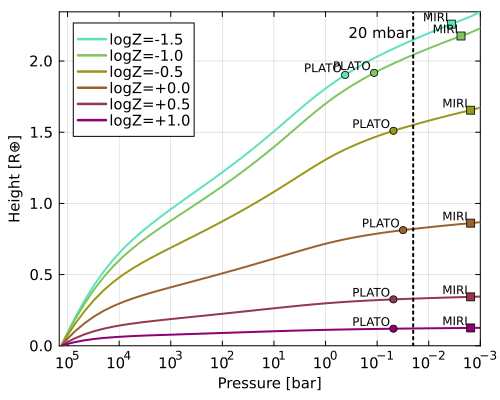

"/home/harrison/Projects/AGNI/out/transspec.pdf"

In [161]:
font = "DejaVuSans"

plt=nothing

plt = plot(legend=:topleft, 
            fontfamily=font,
            guidefontsize=10,
            tickfontsize=10,
            legendfontsize=10,
            right_margin=3Plots.mm,
            size=(500,400), framestyle=:box)

p = reverse(Plots.palette(:hawaii, length(atmos_results)))

x = atmos.pl/1e5
xlims  = (x[1], x[end]*1.1)
xticks = 10.0 .^ round.(Int,range( log10(xlims[1]), stop=log10(xlims[2]), step=1))

lw = 2.0

for (i,logZ) in enumerate(logZ_arr)

    if logZ<-1.8
        continue
    end

    k = "$(logZ)"
    atm = atmos_results[k]
    println(logZ)
    println(atm.gas_vmr["H2O"][end])

    # PLATO red/blue filter overlap
    atm.transspec_ref_wl = 0.675e-6
    energy.radtrans!(atm, true, calc_cf=true)
    atmosphere.estimate_photosphere!(atm)
    plato_p = atm.transspec_p/1e5
    plato_r = (atm.transspec_r - atm.rp)/R_earth

    atm.transspec_ref_wl = 15e-6
    energy.radtrans!(atm, true, calc_cf=true)
    atmosphere.estimate_photosphere!(atm)
    miri_p = atm.transspec_p/1e5
    miri_r = (atm.transspec_r - atm.rp)/R_earth
    
    col = p[i]
    
    # lbl = @sprintf("logZ=%4s, PLATO=%5.1f mbar, MIRI=%3.1f mbar",k,plato_p*1e3, miri_p*1e3)
    lbl = @sprintf("logZ=%+.1f",logZ)

    y = (atm.rl .- atm.rp)/R_earth
    x = atm.pl/1e5
    plot!(plt, x,y, label=lbl, color=col, linewidth=lw)

    # plato
    # hline!(plt, [plato_r], color=col, linestyle=:dot, linewidth=lw)
    scatter!(plt, [plato_p], [plato_r], color=col, marker=:circle)
    annotate!(plt, plato_p*1.2, plato_r+0.05, Plots.text("PLATO", 8, :black, :right,  font, rotation=0))

    # miri
    # hline!(plt, [miri_r], color=col, linestyle=:dash, linewidth=lw)
    scatter!(plt, [miri_p], [miri_r],color=col, marker=:rect)
    annotate!(plt, miri_p*1.2, miri_r+0.05, Plots.text("MIRI", 8, :black, :right, font, rotation=0))
end

vline!(plt, [20e-3], color=:black, linestyle=:dot, lw=2)
annotate!(plt, 20e-3*1.1, 2.2, Plots.text("20 mbar", 10, :black, :right, font))

xaxis!(plt, xscale=:log10, xlims=xlims, xticks=xticks, xlabel="Pressure [bar]", xflip=true)
yaxis!(plt, ylims=(0,Inf), ylabel="Height [R⊕]")

display(plt)
savefig(joinpath(output_dir,"transspec.pdf"))